# 05 — 1D CNN

Standalone notebook. Run `00_Preprocessing.ipynb` first. Each feature
is treated as one timestep with 1 channel (standard tabular→sequence
framing for CNN/RNN architectures on flow-based IDS data).

In [1]:
import os, time
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

from utils import PROCESSED_DIR, RESULTS_DIR, MODELS_DIR, PLOTS_DIR, evaluate, save_results

SEED = 42
tf.random.set_seed(SEED)
MODEL_NAME = "1D CNN"
DL_EPOCHS = 20
DL_BATCH_SIZE = 256


## Load Preprocessed Data

In [2]:
X_train_res = np.load(os.path.join(PROCESSED_DIR, "X_train_res.npy"))
y_train_res = np.load(os.path.join(PROCESSED_DIR, "y_train_res.npy"))
X_test = np.load(os.path.join(PROCESSED_DIR, "X_test.npy"))
y_test = np.load(os.path.join(PROCESSED_DIR, "y_test.npy"))
class_names = joblib.load(os.path.join(PROCESSED_DIR, "class_names.joblib"))
n_classes = joblib.load(os.path.join(PROCESSED_DIR, "n_classes.joblib"))

X_train_res_seq = X_train_res.reshape((X_train_res.shape[0], X_train_res.shape[1], 1))
X_test_seq = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))
print(f"Train: {X_train_res_seq.shape}, Test: {X_test_seq.shape}, classes: {n_classes}")


Train: (6457965, 78, 1), Test: (131012, 78, 1), classes: 15


## Build & Train

In [3]:
def build_cnn1d(n_features, n_classes):
    model = models.Sequential([
        layers.Input(shape=(n_features, 1)),
        layers.Conv1D(64, kernel_size=3, padding="same", activation="relu"),
        layers.MaxPooling1D(pool_size=2),
        layers.Conv1D(128, kernel_size=3, padding="same", activation="relu"),
        layers.GlobalAveragePooling1D(),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(n_classes, activation="softmax"),
    ])
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model


model = build_cnn1d(X_train_res.shape[1], n_classes)
early_stop = callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

t0 = time.time()
history = model.fit(
    X_train_res_seq, y_train_res, validation_split=0.1,
    epochs=DL_EPOCHS, batch_size=DL_BATCH_SIZE,
    callbacks=[early_stop], verbose=2,
)
train_time = time.time() - t0
print(f"Train time: {train_time:.2f}s")


Epoch 1/20
22704/22704 - 325s - 14ms/step - accuracy: 0.9195 - loss: 0.2694 - val_accuracy: 0.3306 - val_loss: 6.2258
Epoch 2/20
22704/22704 - 375s - 17ms/step - accuracy: 0.9687 - loss: 0.1078 - val_accuracy: 0.3304 - val_loss: 5.9530
Epoch 3/20
22704/22704 - 314s - 14ms/step - accuracy: 0.9765 - loss: 0.0797 - val_accuracy: 0.3302 - val_loss: 6.5857
Epoch 4/20
22704/22704 - 485s - 21ms/step - accuracy: 0.9803 - loss: 0.0669 - val_accuracy: 0.3321 - val_loss: 6.9672
Epoch 5/20
22704/22704 - 364s - 16ms/step - accuracy: 0.9828 - loss: 0.0589 - val_accuracy: 0.3319 - val_loss: 7.6796
Train time: 1885.67s


## Predict & Evaluate

In [4]:
t0 = time.time()
y_proba = model.predict(X_test_seq, verbose=0)
infer_time = time.time() - t0
y_pred = np.argmax(y_proba, axis=1)

row = evaluate(MODEL_NAME, y_test, y_pred, y_proba, train_time, infer_time, n_classes)
for k, v in row.items():
    if k not in ("Confusion Matrix",):
        print(f"{k}: {v}")


Model: 1D CNN
Accuracy: 0.9009556376515129
Precision: 0.35427986812049717
Recall: 0.8461330812491036
F1-Score: 0.4307358717819401
ROC-AUC: 0.9960651041547113
MCC: 0.7715896022141523
Cohen's Kappa: 0.7478799755833226
Train Time (s): 1885.6727039813995
Prediction Time (s): 10.690003156661987


## Training Curves

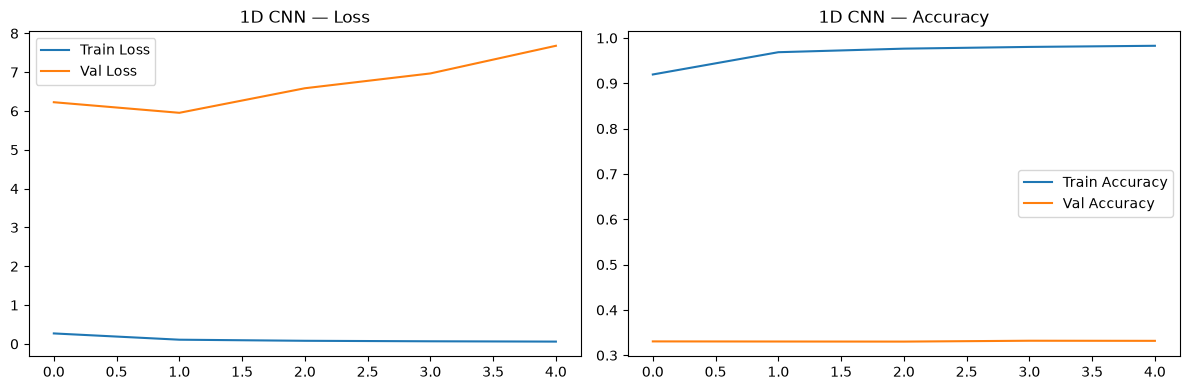

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history["loss"], label="Train Loss")
axes[0].plot(history.history["val_loss"], label="Val Loss")
axes[0].set_title(f"{MODEL_NAME} — Loss"); axes[0].legend()
axes[1].plot(history.history["accuracy"], label="Train Accuracy")
axes[1].plot(history.history["val_accuracy"], label="Val Accuracy")
axes[1].set_title(f"{MODEL_NAME} — Accuracy"); axes[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "CNN1D_training_curves.png"), dpi=150)
plt.show()


## Confusion Matrix Plot

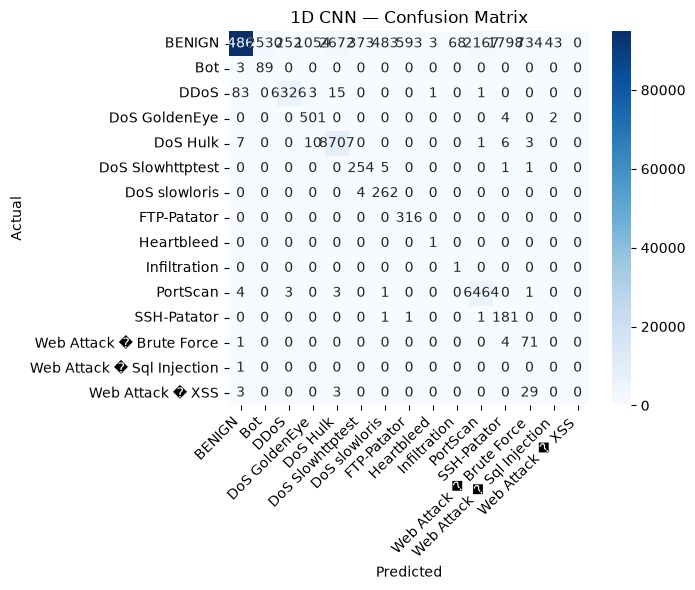

In [6]:
cm = np.array(row["Confusion Matrix"])
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title(f"{MODEL_NAME} — Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "CNN1D_confusion_matrix.png"), dpi=150)
plt.show()


## Save Results & Model

In [7]:
save_results(MODEL_NAME, row, history=history.history)
model.save(os.path.join(MODELS_DIR, "CNN1D.keras"))
print("Saved model and results for", MODEL_NAME)


Saved results to results\1D_CNN_results.json
Saved model and results for 1D CNN
